In [2]:
# ============================================================
# F6 — Week 04 Bayesian Optimisation Pipeline
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# -----------------------------
# Imports (all at top)
# -----------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from scipy.stats import norm

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# ============================================================
# 0) CONFIG
# ============================================================
INPUTS_PATH = "data/F6/initial_inputs.npy"
OUTPUTS_PATH = "data/F6/initial_outputs.npy"

# If you're running in a different environment (e.g., this sandbox),
# you can set these to local fallback paths:
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

RANDOM_SEED = 0

# Acquisition / candidate search
N_CANDIDATES = 120_000
XI = 0.01                 # EI exploration parameter
MIN_DIST = 0.02           # avoid near-duplicates to existing samples

# Bounds for F6 (assumed [0,1] for each dimension)
LOWER_BOUNDS = np.zeros(5)
UPPER_BOUNDS = np.ones(5)

In [4]:
# ============================================================
# 1) LOAD
# ============================================================
def load_npy_with_fallback(primary_path: str, fallback_path: str) -> np.ndarray:
    if os.path.exists(primary_path):
        return np.load(primary_path)
    if os.path.exists(fallback_path):
        return np.load(fallback_path)
    raise FileNotFoundError(f"Could not find {primary_path} or fallback {fallback_path}")

X = load_npy_with_fallback(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y = load_npy_with_fallback(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 5, f"Expected X shape (n,5). Got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,). Got {y.shape}"

n, d = X.shape
best_idx = int(np.argmax(y))
best_y = float(y[best_idx])
best_x = X[best_idx].copy()

print("=== Dataset summary (F6 Week 04) ===")
print(f"n={n}, d={d}")
print(f"y range: min={y.min():.6f}, max={y.max():.6f} (best is closer to 0)")
print(f"best observed y={best_y:.6f} at x={best_x}")

=== Dataset summary (F6 Week 04) ===
n=22, d=5
y range: min=-2.571170, max=-0.495915 (best is closer to 0)
best observed y=-0.495915 at x=[0.411333 0.233733 0.738269 0.982008 0.009039]


In [6]:
# ============================================================
# 2) SURROGATE (Gaussian Process + calibrated noise)
# ============================================================
# Standardise X for GP stability
x_scaler = StandardScaler()
Xs = x_scaler.fit_transform(X)

# Kernel: Constant * RBF(ARD) + White noise
kernel = (
    C(1.0, (1e-2, 1e2))
    * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED,
    alpha=1e-6,   # small extra jitter for numerical robustness
)
gp.fit(Xs, y)

# In-sample fit diagnostics (train sanity check)
mu_train, std_train = gp.predict(Xs, return_std=True)
r2 = r2_score(y, mu_train)

# RMSE compatible with older sklearn versions (no squared= keyword)
rmse = float(np.sqrt(mean_squared_error(y, mu_train)))

print("\n=== GP surrogate fit (train sanity check) ===")
print(f"Kernel learned: {gp.kernel_}")
print(f"Train R²:  {r2:.6f}")
print(f"Train RMSE:{rmse:.6f}")


=== GP surrogate fit (train sanity check) ===
Kernel learned: 1.52**2 * RBF(length_scale=[1.61, 4.7, 3.47, 3.22, 4.66]) + WhiteKernel(noise_level=0.0728)
Train R²:  0.975285
Train RMSE:0.074932


In [7]:
# ============================================================
# 3) ACQUISITION (Expected Improvement for MAXIMISATION)
# ============================================================
rng = np.random.default_rng(RANDOM_SEED)

# Random candidate pool in [0,1]^5
candidates = rng.uniform(LOWER_BOUNDS, UPPER_BOUNDS, size=(N_CANDIDATES, d))
candidates_s = x_scaler.transform(candidates)

mu_cand, std_cand = gp.predict(candidates_s, return_std=True)

# EI (maximisation): EI = E[max(0, f(x)-f_best-xi)]
improvement = mu_cand - best_y - XI
Z = np.divide(improvement, std_cand, out=np.zeros_like(improvement), where=std_cand > 1e-12)
ei = improvement * norm.cdf(Z) + std_cand * norm.pdf(Z)
ei[std_cand <= 1e-12] = 0.0

# Penalise near-duplicates by nearest-neighbour distance to existing X
def min_dist_to_existing(cand: np.ndarray, existing: np.ndarray, chunk: int = 15000) -> np.ndarray:
    mins = []
    for i in range(0, cand.shape[0], chunk):
        c = cand[i:i+chunk]
        d2 = ((c[:, None, :] - existing[None, :, :]) ** 2).sum(axis=2)
        mins.append(np.sqrt(d2.min(axis=1)))
    return np.concatenate(mins)

min_d = min_dist_to_existing(candidates, X)
ei[min_d < MIN_DIST] = 0.0

best_cand_idx = int(np.argmax(ei))
x_next = candidates[best_cand_idx].copy()
x_next_mu = float(mu_cand[best_cand_idx])
x_next_std = float(std_cand[best_cand_idx])
x_next_ei = float(ei[best_cand_idx])
x_next_min_dist = float(min_d[best_cand_idx])

# Clip to bounds (safety)
x_next = np.clip(x_next, LOWER_BOUNDS, UPPER_BOUNDS)


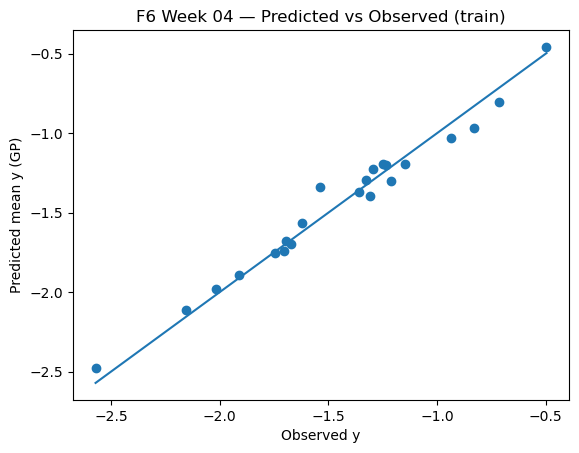

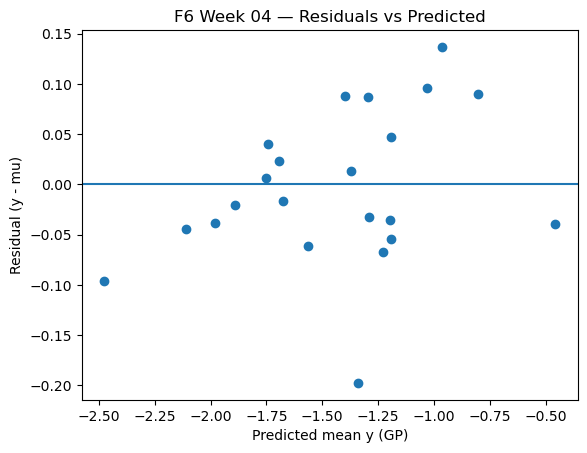

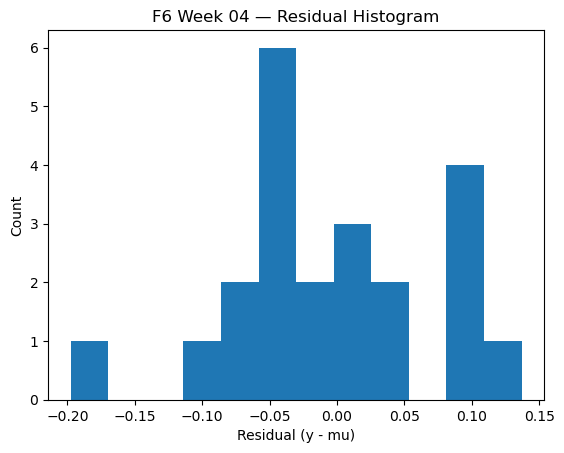

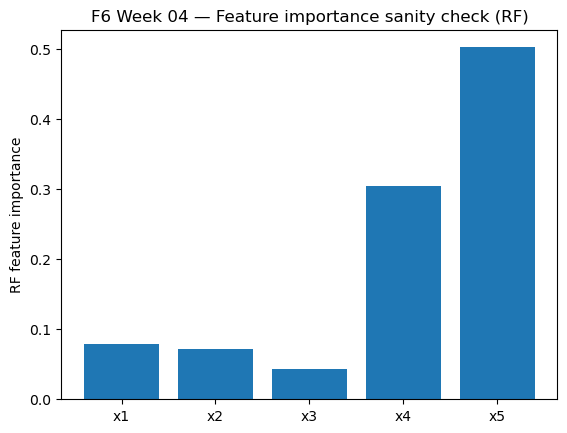

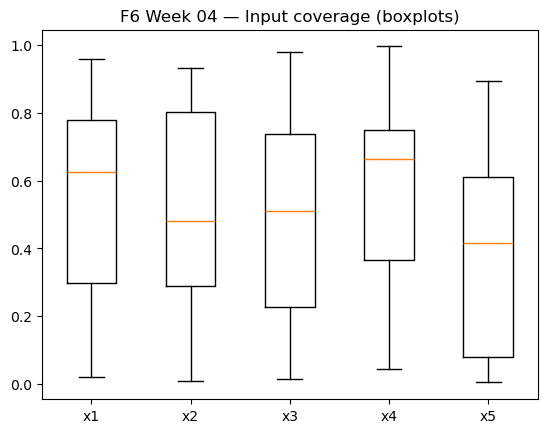


=== Candidate diagnostics ===
Proposed x_next min distance to existing points: 0.269276 (threshold=0.02)
GP predicted mean at x_next: -0.406834
GP predicted std  at x_next: 0.189722
EI(x_next): 0.121710


In [8]:
# ============================================================
# 4) DIAGNOSTICS
# ============================================================
# 4.1 Predicted vs Observed (train)
plt.figure()
plt.scatter(y, mu_train)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Observed y")
plt.ylabel("Predicted mean y (GP)")
plt.title("F6 Week 04 — Predicted vs Observed (train)")
plt.show()

# 4.2 Residuals
residuals = y - mu_train
plt.figure()
plt.scatter(mu_train, residuals)
plt.axhline(0)
plt.xlabel("Predicted mean y (GP)")
plt.ylabel("Residual (y - mu)")
plt.title("F6 Week 04 — Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=12)
plt.xlabel("Residual (y - mu)")
plt.ylabel("Count")
plt.title("F6 Week 04 — Residual Histogram")
plt.show()

# 4.3 Feature importance sanity check (RF)
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=RANDOM_SEED,
    min_samples_leaf=2,
)
rf.fit(X, y)
importances = rf.feature_importances_

plt.figure()
plt.bar([f"x{i+1}" for i in range(d)], importances)
plt.ylabel("RF feature importance")
plt.title("F6 Week 04 — Feature importance sanity check (RF)")
plt.show()

# 4.4 “Are we stuck in one region?” quick check:
# Compare spread of X vs location of best + proposed point
plt.figure()
plt.boxplot([X[:, j] for j in range(d)], tick_labels=[f"x{j+1}" for j in range(d)])
plt.title("F6 Week 04 — Input coverage (boxplots)")
plt.show()

print("\n=== Candidate diagnostics ===")
print(f"Proposed x_next min distance to existing points: {x_next_min_dist:.6f} (threshold={MIN_DIST})")
print(f"GP predicted mean at x_next: {x_next_mu:.6f}")
print(f"GP predicted std  at x_next: {x_next_std:.6f}")
print(f"EI(x_next): {x_next_ei:.6f}")



In [9]:
# ============================================================
# 5) OUTPUT (single line of values)
# ============================================================
np.set_printoptions(suppress=True, precision=6)

print("\n=== NEXT SUBMISSION POINT (one line) ===")
print(x_next)  # <--- submit this 5D vector to your tutor


=== NEXT SUBMISSION POINT (one line) ===
[0.452437 0.001272 0.770306 0.874497 0.073822]
